データ件数: 2311
期間後件数: 847


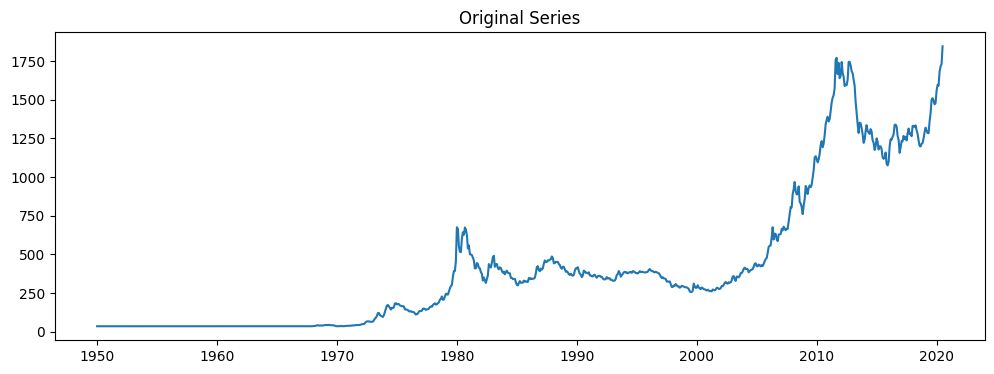

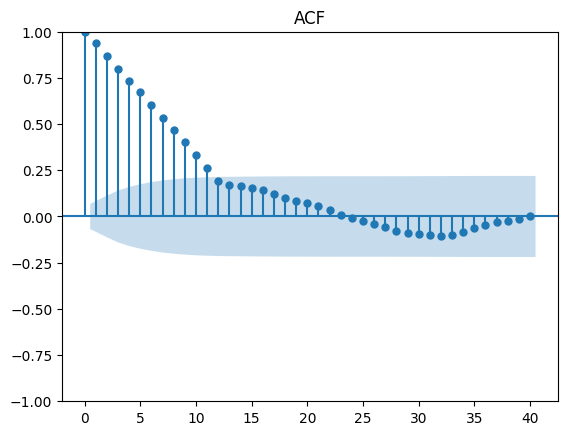

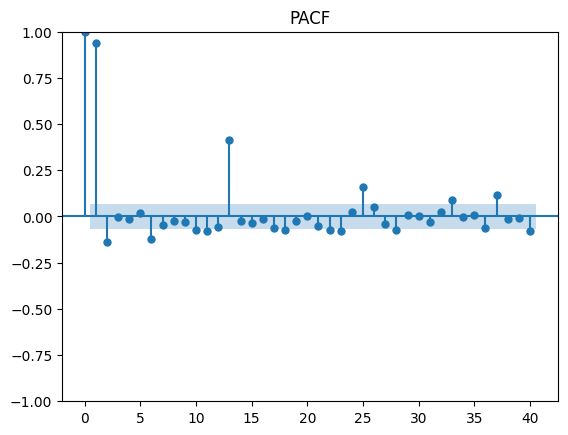


[All Features]
RMSE: 83.41024393362218
MAE : 63.01330540606062
R2  : 0.8123908914232594

特徴量重要度
lag_1     0.885546
lag_2     0.036980
lag_12    0.025424
lag_3     0.017501
month     0.015573
lag_6     0.013900
year      0.005077
dtype: float64


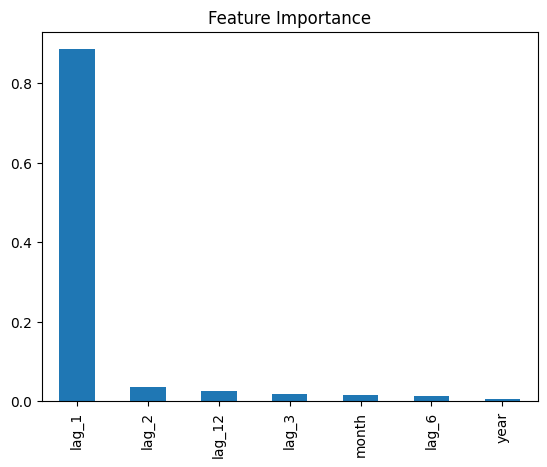


RFE選択特徴量: ['lag_1', 'lag_2', 'lag_3', 'lag_12']

RFEランキング
{'lag_1': np.int64(1), 'lag_2': np.int64(1), 'lag_3': np.int64(1), 'lag_6': np.int64(3), 'lag_12': np.int64(1), 'month': np.int64(2), 'year': np.int64(4)}

[RFE Model]
RMSE: 81.26613421807222
MAE : 62.15884326060605
R2  : 0.8219121300258776


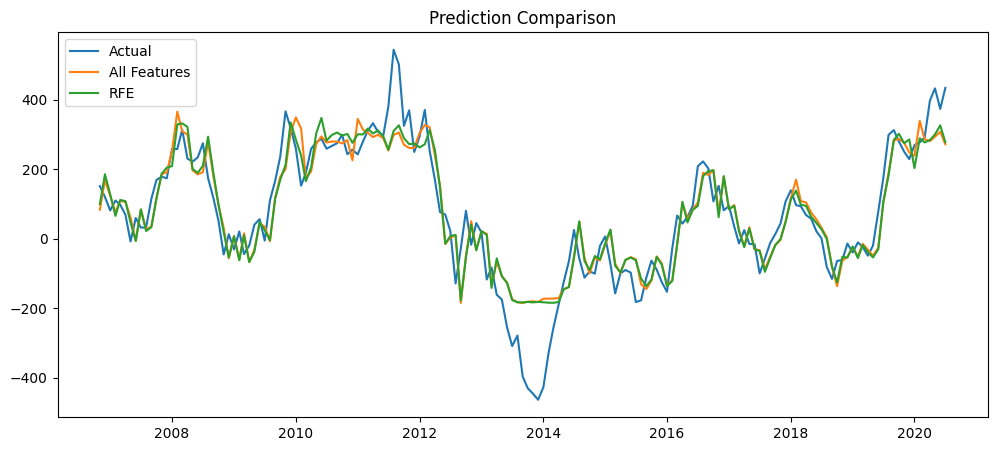

<class 'statsmodels.iolib.summary.Summary'>
"""
                            AutoReg Model Results                             
==============================================================================
Dep. Variable:                   diff   No. Observations:                  823
Model:                    AutoReg(12)   Log Likelihood               -3985.385
Method:               Conditional MLE   S.D. of innovations             32.958
Date:                Thu, 02 Apr 2026   AIC                           7998.771
Time:                        14:40:56   BIC                           8064.546
Sample:                            12   HQIC                          8024.022
                                  823                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.2009      1.193      1.846      0.065      -0.136       4.538
diff.L1        1.1201      0.035     31.787      0.000       1.051       1.189
diff.L2       -0.2370      0.053     -4.465      0.000      -0.341      -0.133
diff.L3        0.0964      0.054      1.789      0.074      -0.009       0.202
diff.L4       -0.0668      0.054     -1.236      0.216      -0.173       0.039
diff.L5        0.1439      0.054      2.657      0.008       0.038       0.250
diff.L6       -0.1055      0.054     -1.941      0.052      -0.212       0.001
diff.L7        0.0195      0.054      0.358      0.721      -0.087       0.126
diff.L8       -0.0390      0.054     -0.719      0.472      -0.145       0.067
diff.L9        0.0449      0.054      0.828      0.408      -0.061       0.151
diff.L10      -0.0057      0.054     -0.106      0.915      -0.112       0.100
diff.L11       0.0061      0.054      0.113      0.910      -0.099       0.111
diff.L12      -0.0616      0.036     -1.716      0.086      -0.132       0.009
                                    Roots                                     
==============================================================================
                   Real          Imaginary           Modulus         Frequency
------------------------------------------------------------------------------
AR.1             1.0564           -0.1236j            1.0636           -0.0185
AR.2             1.0564           +0.1236j            1.0636            0.0185
AR.3             0.9902           -0.7433j            1.2381           -0.1025
AR.4             0.9902           +0.7433j            1.2381            0.1025
AR.5             0.4413           -1.1321j            1.2151           -0.1908
AR.6             0.4413           +1.1321j            1.2151            0.1908
AR.7            -0.2574           -1.3378j            1.3624           -0.2802
AR.8            -0.2574           +1.3378j            1.3624            0.2802
AR.9            -1.2713           -0.4866j            1.3612           -0.4418
AR.10           -1.2713           +0.4866j            1.3612            0.4418
AR.11           -0.9100           -1.0072j            1.3574           -0.3669
AR.12           -0.9100           +1.0072j            1.3574            0.3669
------------------------------------------------------------------------------
"""

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import RFE

# =========================================
# 1. CSV読み込み
# =========================================
df = pd.read_csv("monthly.csv")

# 型変換
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

df = df.dropna(subset=["Date", "Price"]).copy()
df = df.sort_values("Date").reset_index(drop=True)

print("データ件数:", len(df))

# =========================================
# 2. 期間抽出
# =========================================
df = df[(df["Date"] >= "1950-01-01") & (df["Date"] <= "2020-07-01")].copy()
df = df.reset_index(drop=True)

print("期間後件数:", len(df))

# =========================================
# 3. 元系列確認
# =========================================
plt.figure(figsize=(12,4))
plt.plot(df["Date"], df["Price"])
plt.title("Original Series")
plt.show()

# =========================================
# 4. 季節差分（重要）
# =========================================
df["diff"] = df["Price"].diff(12)
df = df.dropna().reset_index(drop=True)

# =========================================
# 5. ACF / PACF
# =========================================
plot_acf(df["diff"], lags=40)
plt.title("ACF")
plt.show()

plot_pacf(df["diff"], lags=40)
plt.title("PACF")
plt.show()

# =========================================
# 6. 特徴量生成（ここが本質）
# =========================================
for lag in [1,2,3,6,12]:
    df[f"lag_{lag}"] = df["diff"].shift(lag)

df["month"] = df["Date"].dt.month
df["year"]  = df["Date"].dt.year

df = df.dropna().reset_index(drop=True)

# =========================================
# 7. X / y
# =========================================
feature_cols = ["lag_1","lag_2","lag_3","lag_6","lag_12","month","year"]

X = df[feature_cols]
y = df["diff"]

# =========================================
# 8. 時系列分割
# =========================================
split = int(len(df)*0.8)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]
date_test = df["Date"].iloc[split:]

# =========================================
# 9. モデル学習
# =========================================
model = RandomForestRegressor(n_estimators=500, random_state=1, n_jobs=-1)
model.fit(X_train, y_train)

# =========================================
# 10. 予測
# =========================================
y_pred = model.predict(X_test)

# =========================================
# 11. 評価
# =========================================
def evaluate(y_true, y_pred, name="model"):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    
    print(f"\n[{name}]")
    print("RMSE:", rmse)
    print("MAE :", mae)
    print("R2  :", r2)

evaluate(y_test, y_pred, "All Features")

# =========================================
# 12. 重要度
# =========================================
importance = pd.Series(model.feature_importances_, index=feature_cols)
importance = importance.sort_values(ascending=False)

print("\n特徴量重要度")
print(importance)

importance.plot(kind="bar", title="Feature Importance")
plt.show()

# =========================================
# 13. RFE（ここ修正版）
# =========================================
rfe_model = RandomForestRegressor(n_estimators=300, random_state=1)

rfe = RFE(rfe_model, n_features_to_select=4)
rfe.fit(X_train, y_train)

selected = [feature_cols[i] for i in range(len(feature_cols)) if rfe.support_[i]]

print("\nRFE選択特徴量:", selected)

# ranking
ranking = dict(zip(feature_cols, rfe.ranking_))
print("\nRFEランキング")
print(ranking)

# =========================================
# 14. RFEモデル
# =========================================
X_train_r = X_train[selected]
X_test_r  = X_test[selected]

model_r = RandomForestRegressor(n_estimators=500, random_state=1)
model_r.fit(X_train_r, y_train)

y_pred_r = model_r.predict(X_test_r)

evaluate(y_test, y_pred_r, "RFE Model")

# =========================================
# 15. 比較プロット
# =========================================
plt.figure(figsize=(12,5))
plt.plot(date_test, y_test, label="Actual")
plt.plot(date_test, y_pred, label="All Features")
plt.plot(date_test, y_pred_r, label="RFE")
plt.legend()
plt.title("Prediction Comparison")
plt.show()


# AR Model

# AR example
from statsmodels.tsa.ar_model import AutoReg
from random import random
# fit model
model = AutoReg(y, lags=1)
model_fit = model.fit()
model_fit.summary()

# AR example
from statsmodels.tsa.ar_model import AutoReg
from random import random
# fit model
model = AutoReg(y, lags=2)
model_fit = model.fit()
model_fit.summary()

# AR example
from statsmodels.tsa.ar_model import AutoReg
from random import random
# fit model
model = AutoReg(y, lags=12)
model_fit = model.fit()
model_fit.summary()

# MA example
from statsmodels.tsa.arima.model import ARIMA
from random import random
# fit model
model = ARIMA(y, order=(0, 0, 1))
model_fit = model.fit()
# make prediction
yhat = model_fit.predict(len(y), len(y))
print(yhat)
model_fit.summary()

